In [ ]:
# All required libraries have been imported successfully
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
# Upload files from your computer in Google Colab environment
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


In [ ]:
# Read the CSV file into a pandas DataFrame
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
# Display first few rows of the dataset (default 5 rows) to quickly preview the data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Display first 10 rows of the dataset to understand the data structure and values
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


Observation:
The first 10 rows of the dataset are displayed successfully. The dataset contains customer information such as gender, tenure, monthly charges, total charges, contract type, and churn status.

In [ ]:
# Get the shape of the dataset (number of rows and columns)
df.shape

(7043, 21)

Observation:
The dataset contains 7043 rows and 21 columns.

In [ ]:
# Check for missing values in each column using isnull() and sum()
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Observation:
Most columns do not contain missing values. We will further check for blank values during preprocessing.

In [ ]:
# Display data types and non-null counts for each column in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Observation:
The dataset contains both numerical and categorical features. Most columns have object data type, while some columns are integer or float type.

In [ ]:
# Display summary statistics (count, mean, std, min, max, quartiles) for numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Observation:
The summary statistics show the count, mean, standard deviation, minimum, maximum, and quartile values for numerical columns.

In [ ]:
# Create a copy of dataframe and encode all categorical columns to numeric for correlation analysis
df_heatmap = df.copy()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df_heatmap.columns:
    if df_heatmap[col].dtype == 'object':
        # Convert text values to numeric codes
        df_heatmap[col] = le.fit_transform(df_heatmap[col].astype(str))

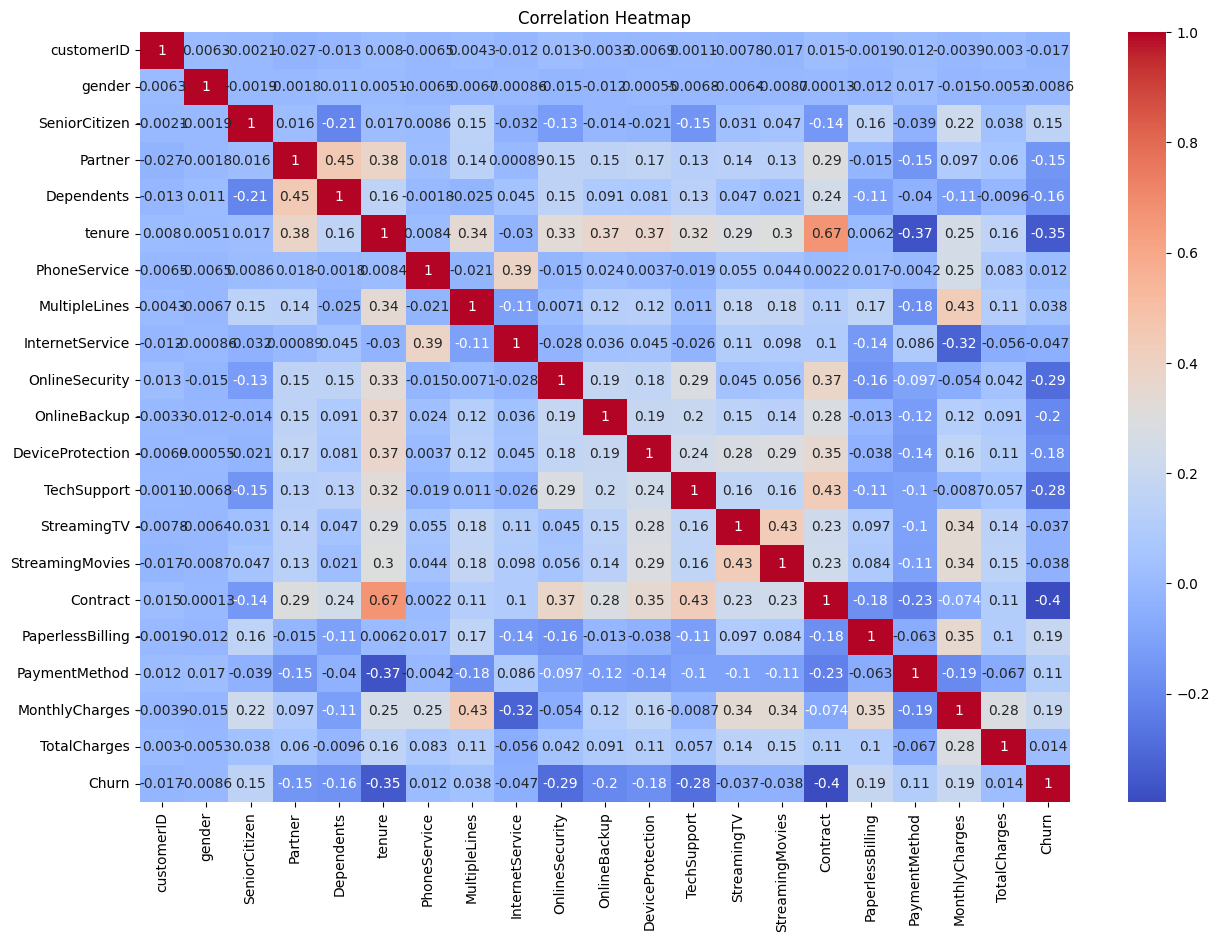

In [ ]:
# Create a correlation heatmap to visualize relationships between all features
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))
sns.heatmap(df_heatmap.corr(), annot=True, cmap='coolwarm')  # annot=True shows correlation values
plt.title("Correlation Heatmap")
plt.show()

Observation:
The heatmap shows the correlation between all features. Some features have positive correlation while others have negative correlation with the target variable (Churn).

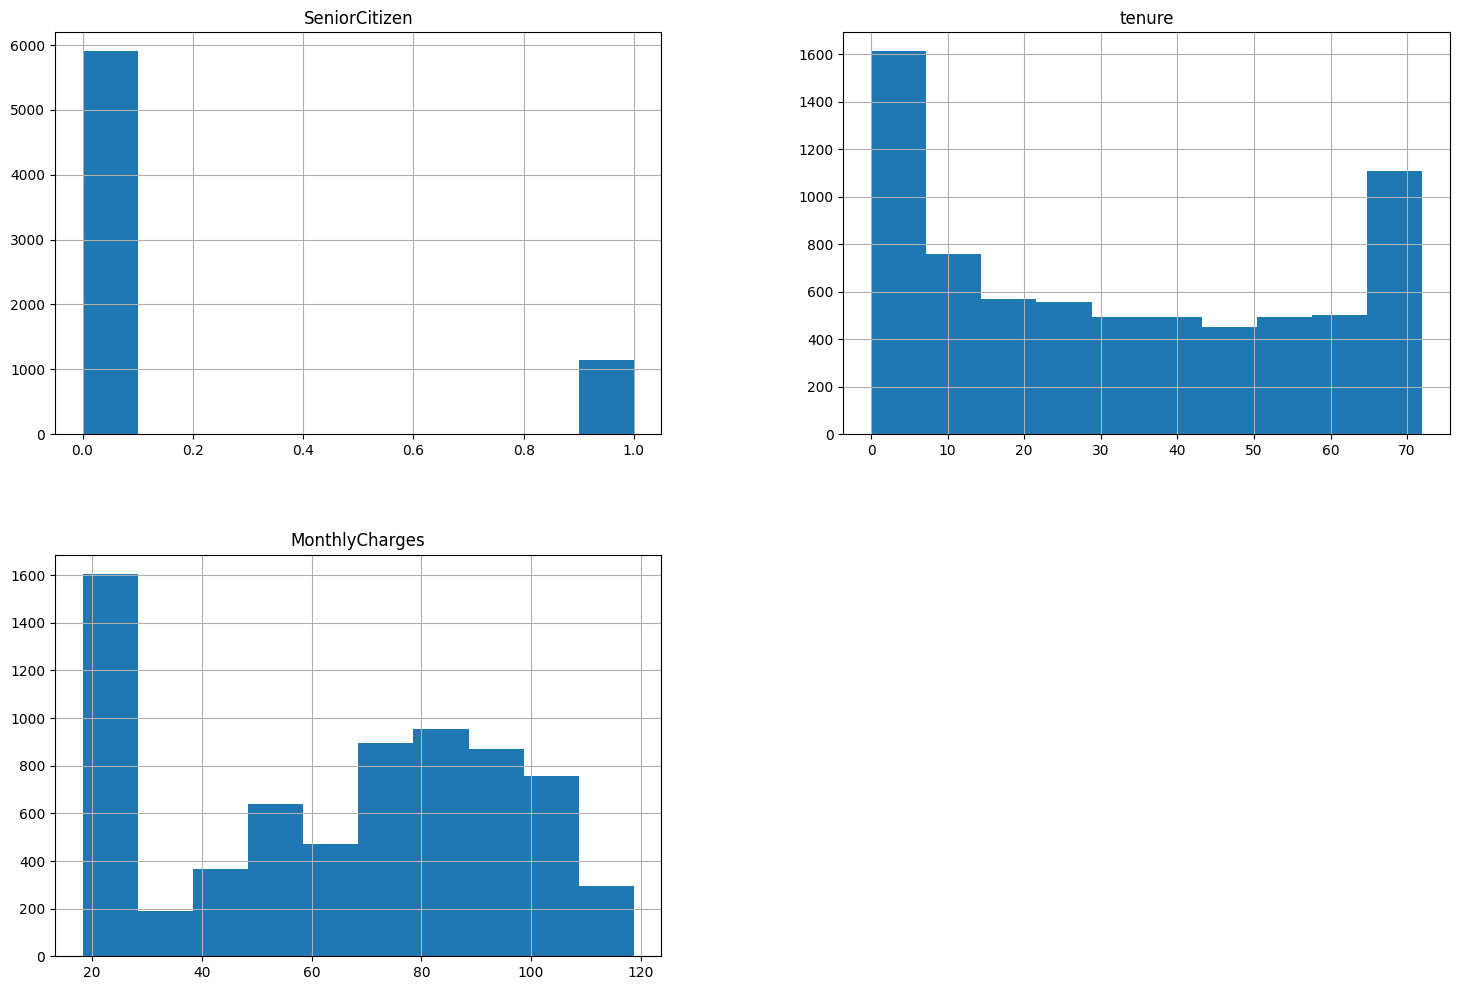

In [ ]:
# Create histograms for all numerical columns to visualize their distributions
df.hist(figsize=(18,12))
plt.show()

Observation:
The histograms show the distribution of numerical features such as tenure, MonthlyCharges, and SeniorCitizen.

In [ ]:
# Check for empty strings ("") in the dataset
(df == "").sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Convert TotalCharges column to numeric format (coerce converts invalid values to NaN)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
# Check again for any missing values after converting TotalCharges to numeric
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Observation:
The TotalCharges column contains some missing values after converting it to numeric format.

In [ ]:
# Fill missing values in TotalCharges column with the median value
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

/tmp/ipykernel_8268/1479199042.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [ ]:
# Drop customerID column as it's just an identifier and doesn't contribute to prediction
df.drop("customerID", axis=1, inplace=True)

Observation:
The customerID column has been removed because it is only a unique identifier and does not help in prediction.

In [ ]:
# Convert categorical (text) columns to numerical values using LabelEncoder
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":  # object dtype means text/categorical data
        df[col] = le.fit_transform(df[col])  # Convert text labels to numbers

In [ ]:
# Standardize numerical features to have mean=0 and standard deviation=1 for better model performance
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df.drop("Churn", axis=1)  # Separate features (independent variables)
y = df["Churn"]  # Separate target (dependent variable)

X = scaler.fit_transform(X)  # Scale all features to same range

Observation:
The numerical features have been standardized so that all features are on a similar scale.

In [ ]:
# Separate features (X) and target variable (y) from the dataset
X = df.drop("Churn", axis=1)  # Features - all columns except Churn
y = df["Churn"]  # Target - the Churn column we want to predict

Observation:
The 'Churn' column is selected as the target variable, and all remaining columns are used as input features.

In [ ]:
# Split dataset into training (80%) and testing (20%) sets for model evaluation
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,  # 20% for testing
    random_state=42  # Fixed seed for reproducible results
)

Observation:
The dataset has been divided into 80% training data and 20% testing data.

In [ ]:
# Create and train a Logistic Regression model for binary classification (churn or no churn)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)  # max_iter for convergence

model.fit(X_train, y_train)  # Train the model using training data

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

Observation:
The Logistic Regression model has been successfully trained using the training dataset.

In [ ]:
# Make predictions on the test data using the trained model
y_pred = model.predict(X_test)

In [ ]:
# Calculate and display the accuracy of the model on the test set
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)  # Compare actual vs predicted values

print("Accuracy :", accuracy * 100, "%")

Accuracy : 81.61816891412349 %


Observation:
The model achieved a good accuracy in predicting customer churn.

In [ ]:
# Display actual vs predicted labels for the first 10 test samples to see model performance
new_predictions = model.predict(X_test[:10])

result = pd.DataFrame({
    "Actual Label": y_test.iloc[:10].values,
    "Predicted Label": new_predictions
})

result

,Actual Label,Predicted Label
0,1,1
1,0,0
2,0,0
3,1,1
4,0,0
5,1,0
6,0,0
7,0,0
8,1,0
9,1,0


Observation:
The model predictions for the first 10 customers are displayed along with their actual labels. Most of the predicted labels match the actual labels, indicating good model performance.

Conclusion:

This project successfully predicts customer churn using the Logistic Regression algorithm.

The dataset was explored, visualized, and preprocessed by handling missing values, encoding categorical variables, removing unnecessary columns, and scaling numerical features.

The model was trained using an 80:20 train-test split and achieved an accuracy of 81.62%, demonstrating good predictive performance.

The final model can be used to identify customers who are likely to leave the company, helping businesses take preventive actions to improve customer retention.